#### Université Paul Sabatier  2025-2026
# Simulations stochastiques - TP5 sur la méthode de Monte-Carlo

In [1]:
%matplotlib inline
from matplotlib.pyplot import *
from math import *
from numpy import *
from numpy.random import *
from scipy.misc import *
from scipy.stats import *

## Exercice 1, basé sur l'exercice 3 du TD4
On considère l'intégrale suivante: 
$$I = \int_{0}^{\infty} e^{-x^2/2} dx.$$
On prend une suite $(X_k)_{k \geq 1}$ de variables exponentielles indépendantes de paramètre $1$,
et on pose $Y_k = e^{X_k - X_k^2/2}$, $I_n = (Y_1 + Y_2 + \dots + Y_n)/n$.
* 3) En TD, on a montré que pour $n$ suffisamment grand, $\mathbb{P} (I \in [I_n -2 \Sigma_n/\sqrt{n},I_n + 2 \Sigma_n/\sqrt{n}])$ est supérieur à $0.95$.

Rappel : $\displaystyle I=\sqrt{\frac{\pi}{2}}$ et $\displaystyle
\Sigma_n=\sqrt{\frac{1}{n}\left(\sum_{k=1}^n Y_k^2\right)-I_n^2}
=\sqrt{\frac{1}{n}\sum_{k=1}^n (Y_k-I_n)^2}$.
* 5) Simuler $N=10000$ fois
le calcul de l'intervalle donné dans 
(3), pour $n = 10000$, et déterminer
combien de fois $I$ tombe en dehors de 
cet intervalle aléatoire. Remarque : $N$ grand pour assurer un résultat significatif dans la LGN. 
$n$ grand pour que l'intervalle de confiance soit de longueur petite (et donc l'estimation de $I$ précise).

In [2]:
N=10**4 #### Plus sûr pour appliquer la LGN que N=100...
n=10**4 #### Pour plus de précision sur la valeur de I, on a pris n plus grand encore.
J=zeros((N,2))
for i in range(N):
    X=-log(rand(n))
    Y=exp(X-X**2/2)
    m=mean(Y) #### C'est I_n
    v=std(Y) ##### C'est Sigma_n
    J[i,0]=m-2*v/sqrt(n)
    J[i,1]=m+2*v/sqrt(n)
vI=sqrt(pi/2)   #### C'est I
#sum(logical_or(vI<J[:,0],vI>J[:,1]))/N
compteur = 0
for i in range(N):
    if vI < J[i,0]:
        compteur+=1
    elif vI > J[i,1]:
        compteur+=1
print("proportion d'intervalles ne contenant pas I :", compteur/N)
print("dernier intervalle obtenu :", J[-1,0],J[-1,1])
print("largeur de l'intervalle de confiance :", 4*v/sqrt(n))
print("valeur exacte de I :", vI)
print('risque asympt. si on prend a=2 :', 2*(1-norm.cdf(2)))

proportion d'intervalles ne contenant pas I : 0.0469
dernier intervalle obtenu : 1.2407046473538044 1.2567316672239128
largeur de l'intervalle de confiance : 0.016027019870108284
valeur exacte de I : 1.2533141373155001
risque asympt. si on prend a=2 : 0.04550026389635842


## Exercice 2 : calcul du niveau effectif d'un intervalle de confaince dans le modèle de Bernoulli

Dans le modèle de Bernoulli (de taille $n$), on observe $x_1, \ldots, x_n$ les réalisations de v.a. i.i.d. $(X_i)_{i=1,\ldots, n}$ de loi de Bernoulli de paramètre $\theta$.

On cherche généralement à estimer $\theta$ à partir des observations, et pour cela l'estimateur utilisé est $\hat{\theta}_n = \frac{1}{n} \sum_{i=1}^n X_i$. On construit également des intervalles de confiance par différentes méthodes. Dans cet exercice nous chercherons à estimer (par Monte-Carlo) le niveau effectif $\Pr(\theta\in I_{BT})$ de l'intervalle de confiance basé sur l'inégalité de Bienaymé-Tchebychev
$$ I_{BT} = \left[ \hat{\theta}_n - \frac{1}{\sqrt{4 n \alpha}},\, \hat{\theta}_n + \frac{1}{\sqrt{4 n \alpha}} \right] $$

On sait que $\sum_{i=1}^n X_i$ suit une loi binomiale de paramètre $(n,\theta)$. Simuler une telle loi peut se faire avec la fonction `binomial` (un exemple est donné ci-dessous). Pour le TP, nous pourrons par exemple choisir `n = 30`, $\alpha=5\%$, et $\theta = 1/2$.

In [4]:
n = 30
binomial(n,.5,10).astype(float) / n

array([0.46666667, 0.6       , 0.5       , 0.33333333, 0.5       ,
       0.5       , 0.63333333, 0.63333333, 0.36666667, 0.46666667])

1. Écrire et tester successivement les fonctions suivantes d'arguments `n`, `p`, `theta`=$\theta$, et `alpha`=$\alpha$, 
   
   a) `proportionsempiriques(n, p, theta)`, qui simule et renvoie `p` réalisations indépendantes de $\hat{\theta}_n$ ;
   
   b) (facultatif) `intervallesBT(n, p, theta, alpha)`, qui représente les `p` réalisations aléatoires indépendantes de $I_{BT}$ associées côte à côte, en distinguant graphiquement les intervalles qui ne continennent pas $\theta$ ; 
   
   c) `niveaueffectifBT(n, p, theta, alpha)`, qui calcule et renvoie la proportion de ces intervalles $I_{BT}$ parmi `p` qui ne contiennent pas $\theta$.

In [5]:
#### question a)


In [3]:
def proportionsempiriques(n,p,theta):
    return binomial(n,theta,p)/n

In [4]:
##### test a) via vérification que l'estimateur est sans biais.
### On estime E_theta(THat) par la moyenne empirique sur le nombre de réalisations indépendantes de THat.
nlist=[15,30,100,1000]
ttheta=0.5
for i in nlist:
    print(mean(proportionsempiriques(i,1000,ttheta))-ttheta)

0.0041999999999999815
-0.00773333333333337
0.002889999999999948
0.0005439999999999889


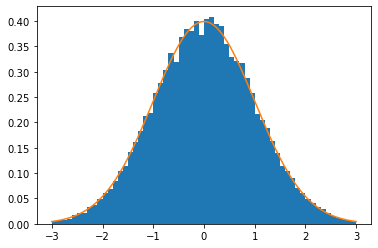

In [8]:
#### test a) via TCL
nn=10**5

ttheta = 0.5
pp=10**5
THat=proportionsempiriques(nn,pp,ttheta)
Z= sqrt(nn)* (THat-ttheta)/(sqrt(ttheta*(1-ttheta)))
xxh=linspace(-3,3,61)
#print(xxh)
hist(Z, bins=xxh ,density=True)
xx=linspace(-3,3,200)
plot(xx,exp(-xx**2/2)/sqrt(2*pi))

In [7]:
#### question b)

In [38]:
#### essai et rappel sur les notations de matrices.
A= array([[0,1,2,3],[4,5,6,7]])
print(A)
print(A[0,1])
print(A[0])
print(A[0][1])
B=A[:,1+arange(3)]
print(B)

[[0 1 2 3]
 [4 5 6 7]]
1
[0 1 2 3]
1
[[1 2 3]
 [5 6 7]]


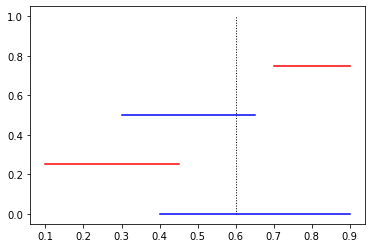

In [6]:
def plotIntervalles(X, val):
    ## Dessine les intervalles donnés dans X (vu comme des lignes de X; X est une matrice p x 2, codant donc
    ##### p intervalles; il faut, pour tout i, X[i,0] <X[i,1]).
    ## En bleu ceux qui contiennent la valeur val, en rouge ceux qui ne la contiennent pas
    plot([val, val], [0,1], ':k', lw=1)
    for i in range(len(X)): ##### incrémente les lignes de X, i.e. les différents intervalles.
        if X[i][0] <= val <= X[i][1]:
            plot(X[i],[float(i) / len(X),float(i) / len(X)],'b') 
            # X[i] contient les deux extrémités du ieme intervalle 
# en ordonnée, un vecteur constant qui décale les intervalles vers le haut, suivant la subdivision adaptée de [0,1]  
        else:
            plot(X[i],[float(i) / len(X),float(i) / len(X)],'r')
## Exemple d'utilisation de plotIntervalles
XX = [[0.4,0.9], [0.1, 0.45], [0.3, 0.65], [0.7,0.9]]
vval=0.6
plotIntervalles(XX, vval)

In [7]:
def intervallesBT(n, p, theta, alpha):
    X=zeros((p,2))
    THat=proportionsempiriques(n,p,theta)
    e = 1/sqrt(4*n*alpha)   #### ecart
    X[:,0]=THat-e
    X[:,1]=THat+e
    plotIntervalles(X, theta)

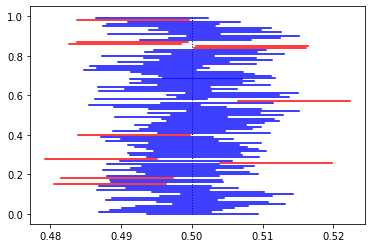

In [10]:
### Test intervallesBT
nn=10**4
pp= 100
ttheta = 0.5
aalpha=0.4
intervallesBT(nn,pp,ttheta,aalpha)

In [13]:
#### c)
def niveaueffectifBT(n, p, theta, alpha):
    X=zeros((p,2))
    THat=proportionsempiriques(n,p,theta)
    e = 1/sqrt(4*n*alpha)   #### ecart
    X[:,0]=THat-e
    X[:,1]=THat+e
    compteur=0
    for i in range(p):
        if theta < X[i,0]:
            compteur+=1
        elif theta > X[i,1]:
            compteur+=1
    prop=compteur/p #### proportion d'intervalles ne contenant pas le paramètre    
    return prop

2. Tester votre fonction `niveaueffectifBT` pour différentes valeurs des arguments. Observer et conclure.

   On étudiera en particulier le cas $n=30$, $p=10^4$, $\alpha=5\%$, et $\theta = 1/2$. Pourquoi est-il pertinent de toujours prendre de grandes valeurs de `p` ?

In [15]:
nn=30
pp=10*4 ### Prendre pp grand permet d'obtenir une approximation significative du résultat 
####  attendu 
### (ie. la proportion d'intervalles déviants) via la LGN.
ttheta=0.5

aalpha = 0.05 #### Pour un tel alpha la proportion est nulle, les intervalles sont 
#### trop grands (trop "conservatifs")
pprop = niveaueffectifBT(nn,pp,ttheta,aalpha)
print("pour alpha = ",aalpha, "la proportion empirique où theta n'appartienne pas à IBT est : ", pprop)

### On prend donc un risque plus grand pour qu'on observe des intervalles ne 
#### comprenant pas le paramètre.

aalpha = 0.4
pprop = niveaueffectifBT(nn,pp,ttheta,aalpha)
print("pour alpha = ",aalpha, "la proportion empirique où theta n'appartienne pas à IBT est : ", pprop)

aalpha= 0.5
pprop = niveaueffectifBT(nn,pp,ttheta,aalpha)
print("pour alpha = ",aalpha, "la proportion empirique où theta n'appartienne pas à IBT est : ", pprop)

#### On constate que, de toute façon, les intervalles IBT sont trop conservatifs. 
#### L'estimation du risque
#### obtenu via la méthode BT est trop grande 
#### (les inégalités sont loin d'être des égalités...)

    



pour alpha =  0.05 la proportion empirique où theta n'appartienne pas à IBT est :  0.0
pour alpha =  0.4 la proportion empirique où theta n'appartienne pas à IBT est :  0.025
pour alpha =  0.5 la proportion empirique où theta n'appartienne pas à IBT est :  0.175


## Exercice 3 : illustration de la LGN forte dans le modèle de Bernoulli

1. Expliquer pourquoi, si on veut illustrer la convergence presque sûre de $\hat{\theta}_n$ vers $\theta$, on ne peut pas simplement utiliser la fonction `binomial(n,...)` pour différentes valeurs successives de `n`.

### Correction
Si on invoque binomial(n,...) pour différents n, on n'obtient des réalisations, mais d'échantillons différents.
L'aléa n'est pas le même pour chacune. Ce qu'il faut faire, c'est considérer des échantillons indépendants de grande taille de v.a. B(1,theta), et pour chacun de ces échantillons, déterminer les valeurs de thetahat(n) pour différentes valeurs de n : les trajectoires thetahat(1), (2), ..., (n).
Et constater qu'on a le même résultat pour tous les échantillons.

2. Écrire une fonction `simuThetaHat(N, p, theta)` qui simule `p` trajectoires indépendantes de $\hat{\theta}_n$ pour `n` entre 1 et `N`. Le rendu devra être sous la forme d'un tableau à `p` lignes et `N` colonnes.

   Indication : simuler $p \times N$ tirages indépendants selon la loi de Bernoulli de paramètre $\theta=$`theta`, les placer dans un tableau, et utiliser des sommes cumulatives et des divisions sur les lignes.

In [9]:
def simuThetaHat(N, p, theta):
    U = rand(p,N) #### p lignes, N colonnes : trajectoires en ligne, c'est plus facile 
    #### à visualiser.
    B=(U<theta).astype(float) #### Les Bernoulli B(1,theta) indépendantes
    That=zeros((p,N)) #### Déclaration du tableau destiné à recueillir les trajectoires
    for i in range(p): #### Entrée des trajectoires, ligne à ligne
        That[i]=cumsum(B[i])/(1+arange(N))
    return(That)

TThat=simuThetaHat(10,5,0.5) # On imprime pour N et p petit pour tester la fonction.
print("Le tableau obtenu",TThat)




Le tableau obtenu [[1.         0.5        0.33333333 0.25       0.2        0.33333333
  0.28571429 0.25       0.33333333 0.4       ]
 [0.         0.         0.         0.         0.         0.16666667
  0.28571429 0.25       0.22222222 0.2       ]
 [1.         1.         1.         0.75       0.8        0.83333333
  0.71428571 0.75       0.77777778 0.8       ]
 [1.         0.5        0.66666667 0.5        0.4        0.33333333
  0.28571429 0.375      0.44444444 0.5       ]
 [0.         0.         0.         0.         0.         0.
  0.14285714 0.125      0.11111111 0.2       ]]


3. Tester la fonction `simuThetaHat(N, p, theta)` de la question précédente, et en exploiter la sortie pour représenter graphiquement plusieurs trajectoires de la suite $(\hat{\theta}_n)_n$.

   On pourra éventuellement choisir `p` assez petit, et colorier différemment les trajectoires. En revanche `N` assez grand (`N=10**4` par exemple) aidera à visualiser le comportement asymptotique.

lignes 3
colonnes 10000


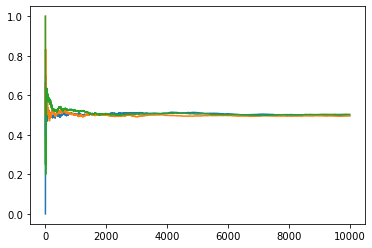

In [13]:
NN = 10**4 
ttheta = 0.5
pp=3
TTHat=simuThetaHat(NN,pp,ttheta)
for i in range(pp):
    plot(TTHat[i])
print("lignes",len(TTHat))
print("colonnes", len(TTHat[0]))

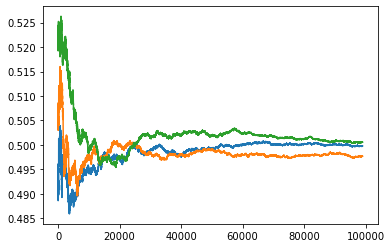

In [17]:
# Et pour y voir plus clair, tracé à partir de n=1000
NN = 10**5 #### Choisir 10**4, 10**5, 10**6
ttheta = 0.5
pp=3
TTHat=simuThetaHat(NN,pp,ttheta)
YY=TTHat[:,1000+arange(NN-1000)]
for i in range(pp):
    plot(YY[i]) 

## Et un exercice corrigé : tests pour le modèle de Bernoulli

On se place dans le modèle de Bernoulli, où on rappelle qu'on observe un échantillon $X_1,X_2,\ldots,X_n \stackrel{\textrm{i.i.d.}}{\sim}{\cal B}(\theta)$ avec $\theta \in ]0,1[$ inconnu.  On considère les deux hypothèses :   $H_0: \theta \leq \theta_0$ et $H_1: \theta > \theta_0$.

L'objectif de l'exercice est de manipuler numériquement les tests du cours sur le paramètre $\theta$ qu'on a construits avec l'inégalité de Bienaymé-Tchebychev et avec le TCL ; on notera ces 2 tests $\phi_n^{BT}$ et $\phi_n^{TCL}$.

Les simulations seront réalisées avec différentes tailles d'échantillon $n$, et avec $\theta_0 = 0.4$ et $\alpha = 0.05$.
* 1) Rappeler les expressions des tests $\phi_n^{BT}$ et $\phi_n^{TCL}$ construits en cours avec l'inégalité de Bienaymé-Tchebychev et avec le TCL.

Réponse : $\phi_n=1_{\hat\theta_n>\theta_0+\Delta_\alpha}$, où $\displaystyle\hat\theta_n=\frac{X_1+\ldots+X_n}{n}$  
et $\displaystyle \Delta_\alpha=\frac{1}{\sqrt{4\alpha n}}$ pour $\phi_n^{BT}$,
$\displaystyle \Delta_\alpha=q_{1-\alpha}\sqrt{\frac{\theta_0(1-\theta_0)}{n}}$ pour $\phi_n^{TCL}$.
* 2) On prend $\theta=\theta_0=0.4$. Pour chaque valeur de $n \in \{3,10,100,1000\}$, simuler $N_{\textrm{sim}} = 10^4$ échantillons de taille $n$ et vérifier pour chaque échantillon si les tests $\phi_n^{BT}$ et $\phi_n^{TCL}$ conservent ou rejettent l'hypothèse $H_0$. En déduire une estimation $\hat{r}_1^{BT}$ et $\hat{r}_1^{TCL}$ de la probabilité $\mathbb{P}_{\theta_0}\bigl(\phi_n(X_1,\ldots,X_n)=1\bigr)$ pour chacun des deux tests.  
A quoi correspond cette probabilité ? A-t-on bien $\hat{r}_1^{BT/TCL} \lesssim \alpha$ comme attendu ? Est-ce vrai pour tout $n$ ?

In [26]:
th0=0.4 
th=th0 #### Cas où H0 est vérifiée : détermination du risque de première espèce effectif.
a=0.05
nn=[3,10,100,1000,10000]
Nsim=10**4 # ou valeurs plus grandes !
for n in nn:
    r1BT=mean(binomial(n,th,Nsim)/n>th0+1/sqrt(4*n*a))
    r1TCL=mean(binomial(n,th,Nsim)/n>th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))
    #### ppf = percent point function
    print("n =",n,"donne r1BT =",r1BT,"et r1TCL =",r1TCL)

n = 3 donne r1BT = 0.0 et r1TCL = 0.0599
n = 10 donne r1BT = 0.0 et r1TCL = 0.0516
n = 100 donne r1BT = 0.0 et r1TCL = 0.0437
n = 1000 donne r1BT = 0.0 et r1TCL = 0.0512
n = 10000 donne r1BT = 0.0 et r1TCL = 0.0453


In [28]:
th=0.45 #### Cas où H1 est vérifiée. Et theta assez loin de la limite theta0. Détermination du rique de deuxième
#### espèce effectif. 
for n in nn:
    r2BT = mean(binomial(n,th,Nsim)/n <= th0+1/sqrt(4*n*a))
    r2TCL = mean(binomial(n,th,Nsim)/n <= th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))
    print("n =",n,"donne r2BT =",r2BT,"et r2TCL =",r2TCL)

n = 3 donne r2BT = 1.0 et r2TCL = 0.9037
n = 10 donne r2BT = 1.0 et r2TCL = 0.8984
n = 100 donne r2BT = 0.9999 et r2TCL = 0.7578
n = 1000 donne r2BT = 0.907 et r2TCL = 0.0618
n = 10000 donne r2BT = 0.0 et r2TCL = 0.0


In [29]:
th=0.45 #### Cas où H1 est vérifiée. Et theta assez loin de la limite theta0. Détermination du rique de deuxième
#### espèce effectif associé. Moins bon pour BT que pour TCL. Mais tend vers 0 avec n.
for n in nn:
    r2BT = mean(binomial(n,th,Nsim)/n <= th0+1/sqrt(4*n*a))
    r2TCL = mean(binomial(n,th,Nsim)/n <= th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))
    print("n =",n,"donne r2BT =",r2BT,"et r2TCL =",r2TCL)

n = 3 donne r2BT = 1.0 et r2TCL = 0.9105
n = 10 donne r2BT = 1.0 et r2TCL = 0.899
n = 100 donne r2BT = 0.9995 et r2TCL = 0.7656
n = 1000 donne r2BT = 0.9067 et r2TCL = 0.0612
n = 10000 donne r2BT = 0.0 et r2TCL = 0.0


In [31]:
# On a estimé ci-dessus le risque de seconde espèce du test relatif à la valeur alternative theta=0.45
# Pas étonnant que ce risque soit plus grand pour phi-BT car ce test est plus conservateur (région de rejet plus petite)
# Plus précisément :
n=1000
print("n = ", n)
print("seuil de rejet de H0 pour phi-BT : ",th0+1/sqrt(4*n*a))
print("seuil de rejet pour phi-TCL : ",th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))
n=10000
print("n = ", n)
print("seuil de rejet pour phi-BT : ",th0+1/sqrt(4*n*a))
print("seuil de rejet pour phi-TCL : ",th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))

n =  1000
seuil de rejet pour phi-BT :  0.47071067811865475
seuil de rejet pour phi-TCL :  0.4254819628165277
n =  10000
seuil de rejet pour phi-BT :  0.4223606797749979
seuil de rejet pour phi-TCL :  0.4080581041751947
